# Load the Data :

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
%matplotlib inline

import string
import nltk

from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split 
from sklearn import metrics

In [2]:
data = pd.read_csv(r"C:\Users\Pooja Dhingiya\Downloads\sms_spam_dataset.csv",encoding = 'latin-1')
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
data.tail()

,v1,v2
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


# Exploratory Data Analysis :

In [6]:
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [8]:
data.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
data = data.rename(columns={'v1': 'label', 'v2': 'message'})


In [12]:
data.groupby('label').describe().T


label                              ham  \
message count                     4825   
        unique                    4516   
        top     Sorry, I'll call later   
        freq                        30   

label                                                        spam  
message count                                                 747  
        unique                                                653  
        top     Please call our customer service representativ...  
        freq                                                    4

In [15]:
data = data.rename(columns={'v1': 'label', 'v2': 'message'})
data['length'] = data['message'].apply(len)
data.head()


,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [17]:
# frequency of top 5 messages.
data['message'].value_counts().rename_axis(['message']).reset_index(name='counts').head()

,message,counts
0,"Sorry, I'll call later",30
1,I cant pick the phone right now. Pls send a me...,12
2,Ok...,10
3,Okie,4
4,Your opinion about me? 1. Over 2. Jada 3. Kusr...,4


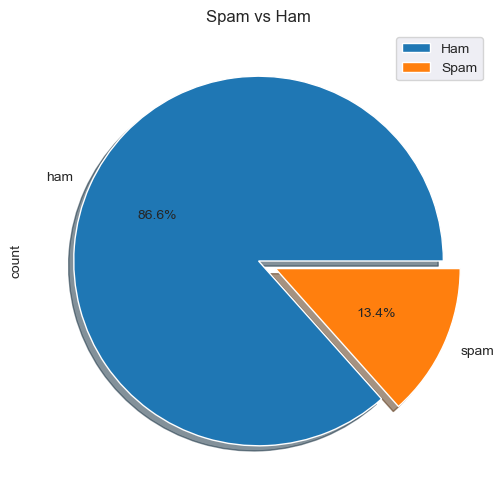

In [18]:
data["label"].value_counts().plot(kind = 'pie',explode=[0, 0.1],figsize=(6, 6),autopct='%1.1f%%',shadow=True)
plt.title("Spam vs Ham")
plt.legend(["Ham", "Spam"])
plt.show()

Text(0, 0.5, 'Frequency')

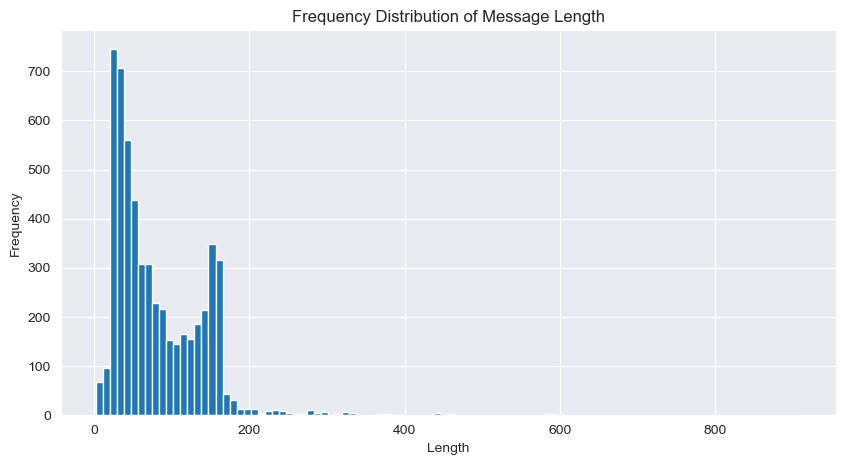

In [19]:
plt.figure(figsize=(10,5))
data['length'].plot(bins=100, kind='hist') 
plt.title("Frequency Distribution of Message Length")
plt.xlabel("Length")
plt.ylabel("Frequency")

In [20]:
data['length'].describe()

count    5572.000000
mean       80.616296
std        60.015593
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: length, dtype: float64

In [21]:
data[data['length'] == 910]['message'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

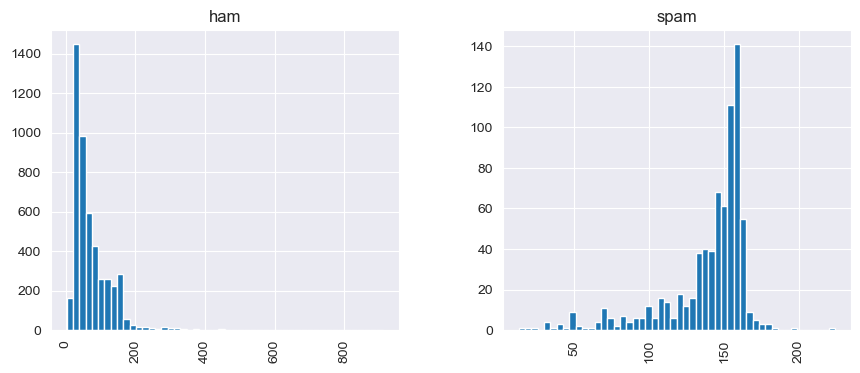

In [22]:
data.hist(column='length', by='label', bins=50,figsize=(10,4))

# Data - Preprocessing :

In [23]:
def text_preprocess(mess):
    """
    Takes in a string of text, then performs the following:
    1. Remove all punctuation
    2. Remove all stopwords
    3. Returns a list of the cleaned text
    """
    nopunc = [char for char in mess if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    nopunc = nopunc.lower()
    
    nostop=[word for word in nopunc.split() if word.lower() not in 
            stopwords.words('english') and word.isalpha()]
    return nostop

In [24]:
spam_messages = data[data["label"] == "spam"]["message"]
ham_messages = data[data["label"] == "ham"]["message"]
print("No of spam messages : ",len(spam_messages))
print("No of ham messages : ",len(ham_messages))

No of spam messages :  747
No of ham messages :  4825


In [25]:
spam_words = text_preprocess(spam_messages)

In [26]:
spam_words[:10]

['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'may']

In [27]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Pooja
[nltk_data]     Dhingiya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

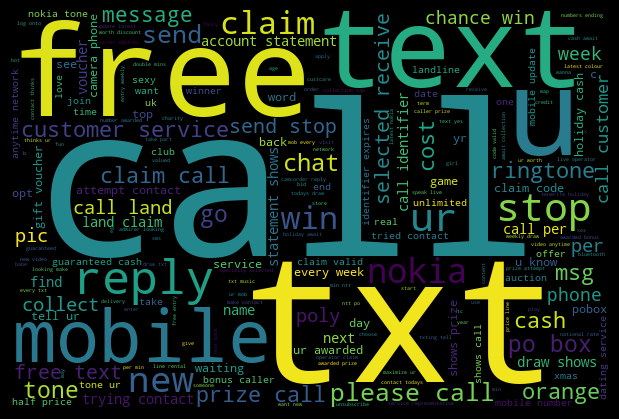

In [28]:
spam_wordcloud = WordCloud(width=600, height=400).generate(' '.join(spam_words))
plt.figure( figsize=(6,4), facecolor='k')
plt.imshow(spam_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [29]:
print("Top 10 Spam words are :\n")
print(pd.Series(spam_words).value_counts().head(10))

Top 10 Spam words are :

call      331
free      146
txt       136
ur        129
mobile    108
text      107
claim     105
reply      98
u          98
stop       79
Name: count, dtype: int64


In [30]:
ham_words = text_preprocess(ham_messages)

In [31]:
ham_words[:10]

['go',
 'jurong',
 'available',
 'bugis',
 'n',
 'great',
 'world',
 'la',
 'e',
 'cine']

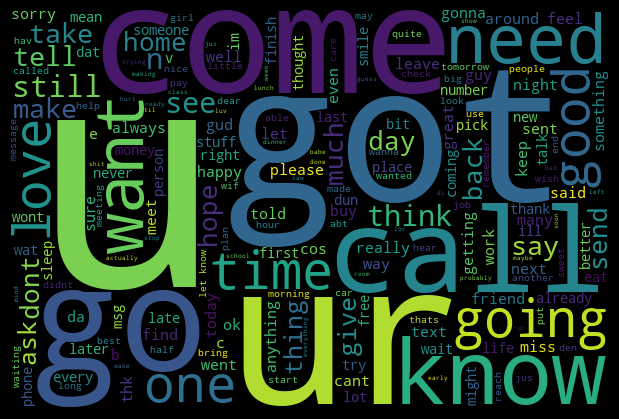

In [32]:
ham_wordcloud = WordCloud(width=600, height=400).generate(' '.join(ham_words))
plt.figure( figsize=(6,4), facecolor='k')
plt.imshow(ham_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [33]:
print("Top 10 Ham words are :\n")
print(pd.Series(ham_words).value_counts().head(10))

Top 10 Ham words are :

u        827
get      287
ur       241
go       234
got      217
like     217
come     204
call     202
know     202
going    151
Name: count, dtype: int64


# Data Cleaning :

In [34]:
data.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [35]:
# remove punctuations/ stopwords from all SMS 
data["message"] = data["message"].apply(text_preprocess)

In [36]:
# Convert the SMS into string from list
data["message"] = data["message"].agg(lambda x: ' '.join(map(str, x)))

In [37]:
data.head()

,label,message,length
0,ham,go jurong point crazy available bugis n great ...,111
1,ham,ok lar joking wif u oni,29
2,spam,free entry wkly comp win fa cup final tkts may...,155
3,ham,u dun say early hor u c already say,49
4,ham,nah dont think goes usf lives around though,61


In [38]:
data['message'][7]

'per request melle melle oru minnaminunginte nurungu vettam set callertune callers press copy friends callertune'

#  Continuing Normalization :

In [39]:
vectorizer = CountVectorizer()
bow_transformer = vectorizer.fit(data['message'])

print("20 Bag of Words (BOW) Features: \n")
print(vectorizer.get_feature_names_out()[20:40])

print("\nTotal number of vocab words: ", len(vectorizer.vocabulary_))


20 Bag of Words (BOW) Features: 

['absence' 'absolutely' 'abstract' 'abt' 'abta' 'aburo' 'abuse' 'abusers'
 'ac' 'academic' 'acc' 'accent' 'accenture' 'accept' 'access' 'accessible'
 'accidant' 'accident' 'accidentally' 'accommodation']

Total number of vocab words:  8129


In [40]:
message4 = data['message'][3]
print(message4)

u dun say early hor u c already say


In [41]:
vectorizer = CountVectorizer()
bow_transformer = vectorizer.fit(data['message'])

print("20 Bag of Words (BOW) Features: \n")
print(vectorizer.get_feature_names_out()[20:40])

print("\nTotal number of vocab words : ", len(vectorizer.vocabulary_))


20 Bag of Words (BOW) Features: 

['absence' 'absolutely' 'abstract' 'abt' 'abta' 'aburo' 'abuse' 'abusers'
 'ac' 'academic' 'acc' 'accent' 'accenture' 'accept' 'access' 'accessible'
 'accidant' 'accident' 'accidentally' 'accommodation']

Total number of vocab words :  8129


In [42]:
bow4 = bow_transformer.transform([message4])
print(bow4)
print(bow4.shape)

  (0, 208)	1
  (0, 1986)	1
  (0, 2005)	1
  (0, 3158)	1
  (0, 5982)	2
(1, 8129)


In [43]:
vectorizer = CountVectorizer()
bow_transformer = vectorizer.fit(data['message'])

print(vectorizer.get_feature_names_out()[5945])


samus


In [44]:
messages_bow = bow_transformer.transform(data['message'])

In [45]:
print('Shape of Sparse Matrix: ', messages_bow.shape)
print('Amount of Non-Zero occurences: ', messages_bow.nnz)

Shape of Sparse Matrix:  (5572, 8129)
Amount of Non-Zero occurences:  44383


In [46]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer().fit(messages_bow)

In [47]:
tfidf4 = tfidf_transformer.transform(bow4)
print(tfidf4)

  (0, 5982)	0.619775084625881
  (0, 3158)	0.5143873498708452
  (0, 2005)	0.37159298853883077
  (0, 1986)	0.3423052157911949
  (0, 208)	0.3098875423129405


In [48]:
print(bow_transformer.get_feature_names_out()[5945])
print(bow_transformer.get_feature_names_out()[3141])


samus
hoo


In [49]:
vectorizer = CountVectorizer()
vectorizer.fit(data['message'])

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

print("Word at index 3141:", vectorizer.get_feature_names_out()[3141])
print("Word at index 5945:", vectorizer.get_feature_names_out()[5945])


Vocabulary size: 8129
Word at index 3141: hoo
Word at index 5945: samus


In [50]:
print(tfidf_transformer.idf_[bow_transformer.vocabulary_['say']])

5.137052417837396


In [51]:
messages_tfidf = tfidf_transformer.transform(messages_bow)
print(messages_tfidf.shape)

(5572, 8129)


In [52]:
data["message"][:10]

0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts may...
3                  u dun say early hor u c already say
4          nah dont think goes usf lives around though
5    freemsg hey darling weeks word back id like fu...
6       even brother like speak treat like aids patent
7    per request melle melle oru minnaminunginte nu...
8    winner valued network customer selected receiv...
9    mobile months u r entitled update latest colou...
Name: message, dtype: object

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(encoding = "latin-1", strip_accents = "unicode", stop_words = "english")
features = vec.fit_transform(data["message"])
print(features.shape)

print(len(vec.vocabulary_))

(5572, 7973)
7973


In [54]:
msg_train, msg_test, label_train, label_test = \
train_test_split(messages_tfidf, data['label'], test_size=0.2)

In [55]:
print("train dataset features size : ",msg_train.shape)
print("train dataset label size", label_train.shape)

print("\n")

print("test dataset features size", msg_test.shape)
print("test dataset lable size", label_test.shape)

train dataset features size :  (4457, 8129)
train dataset label size (4457,)


test dataset features size (1115, 8129)
test dataset lable size (1115,)


# Navie Bayes Classifier Model :

In [56]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()
spam_detect_model = clf.fit(msg_train, label_train)

In [57]:
predict_train = spam_detect_model.predict(msg_train)

In [58]:
print("Classification Report \n",metrics.classification_report(label_train, predict_train))
print("\n")
print("Confusion Matrix \n",metrics.confusion_matrix(label_train, predict_train))
print("\n")
print("Accuracy of Train dataset : {0:0.3f}".format(metrics.accuracy_score(label_train, predict_train)))

Classification Report 
               precision    recall  f1-score   support

         ham       0.97      1.00      0.98      3866
        spam       1.00      0.80      0.89       591

    accuracy                           0.97      4457
   macro avg       0.99      0.90      0.94      4457
weighted avg       0.97      0.97      0.97      4457



Confusion Matrix 
 [[3866    0]
 [ 118  473]]


Accuracy of Train dataset : 0.974


In [59]:
print('predicted:', spam_detect_model.predict(tfidf4)[0])
print('expected:', data['label'][3])

predicted: ham
expected: ham


In [60]:
label_predictions = spam_detect_model.predict(msg_test)
print(label_predictions)

['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']


In [61]:
print(metrics.classification_report(label_test, label_predictions))
print(metrics.confusion_matrix(label_test, label_predictions))

              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       959
        spam       1.00      0.69      0.82       156

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.95      1115

[[959   0]
 [ 48 108]]


In [62]:
# Printing the Overall Accuracy of the model
print("Accuracy of the model : {0:0.3f}".format(metrics.accuracy_score(label_test, label_predictions)))

Accuracy of the model : 0.957


In [63]:
print('predicted:', spam_detect_model.predict(tfidf4)[0])
print('expected:', data['label'][10])

predicted: ham
expected: ham


In [64]:
tfidf4 = vectorizer.transform(["free free free"])
print('predicted:', spam_detect_model.predict(tfidf4)[0])


predicted: spam


In [65]:
import pickle

# Save the vectorizer
with open("vectorizer.pkl", "wb") as vec_file:
    pickle.dump(vectorizer, vec_file)

# Save the trained model
with open("spam_model.pkl", "wb") as model_file:
    pickle.dump(spam_detect_model, model_file)


In [66]:
# Load the model and vectorizer
with open("vectorizer.pkl", "rb") as vec_file:
    vectorizer = pickle.load(vec_file)

with open("spam_model.pkl", "rb") as model_file:
    spam_detect_model = pickle.load(model_file)

# Function to predict if a message is spam or not
def predict_message(message):
    transformed_message = vectorizer.transform([message])
    prediction = spam_detect_model.predict(transformed_message)[0]
    return "Spam" if prediction == 1 else "Not Spam"

# Test it
test_message = "Congratulations! You've won a free vacation."
print(f"Message: {test_message}\nPrediction: {predict_message(test_message)}")


Message: Congratulations! You've won a free vacation.
Prediction: Not Spam


In [67]:
# Debugging: Check vectorizer transformation
test_message = ["Congratulations! You've won a free vacation."]
transformed_message = vectorizer.transform(test_message)

print("Transformed Input Shape:", transformed_message.shape)
print("Model Prediction:", spam_detect_model.predict(transformed_message))
print("Prediction Probability:", spam_detect_model.predict_proba(transformed_message))


Transformed Input Shape: (1, 8129)
Model Prediction: ['spam']
Prediction Probability: [[0.2020592 0.7979408]]


In [ ]:
def predict_message(message):
    transformed_message = vectorizer.transform([message])
    prediction = spam_detect_model.predict(transformed_message)[0]  # 'spam' or 'ham'

    # Use probability to verify confidence
    prediction_proba = spam_detect_model.predict_proba(transformed_message)[0]

    return f"Spam ({prediction_proba[1]*100:.2f}%)" if prediction == "spam" else f"Not Spam ({prediction_proba[0]*100:.2f}%)"

# Test again
test_message = "Congratulations! You've won a free vacation."
print(f"Message: {test_message}\nPrediction: {predict_message(test_message)}")


In [69]:
!pip install flask


Defaulting to user installation because normal site-packages is not writeable


In [70]:
import pickle

pickle.dump(spam_detect_model, open('spam_model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))


In [71]:
model = pickle.load(open('spam_model.pkl', 'rb'))
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))


In [ ]:
from flask import Flask, request, render_template_string
import pickle

# Initialize the Flask app
app = Flask(__name__)

# Load your saved model and vectorizer
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))
model = pickle.load(open('spam_model.pkl', 'rb'))

# Create a simple HTML form
html = """

<!doctype html>
<html lang="en">
<head>
    <title>SMS Spam Detector</title>
    <style>
        body {
            background: linear-gradient(to right, #74ebd5, #acb6e5);
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            display: flex;
            flex-direction: column;
            align-items: center;
            justify-content: center;
            height: 100vh;
            margin: 0;
            animation: fadeIn 1s ease-in;
        }

        @keyframes fadeIn {
            from {opacity: 0;}
            to {opacity: 1;}
        }

        h2 {
            color: #333;
            margin-bottom: 20px;
        }

        form {
            display: flex;
            flex-direction: column;
            align-items: center;
            background: white;
            padding: 30px;
            border-radius: 10px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.2);
        }

        input[type="text"] {
            width: 300px;
            padding: 10px;
            margin-bottom: 20px;
            border: 1px solid #ccc;
            border-radius: 5px;
            transition: all 0.3s ease;
        }

        input[type="text"]:focus {
            border-color: #007bff;
            box-shadow: 0 0 8px #007bff;
        }

        input[type="submit"] {
            background-color: #007bff;
            color: white;
            border: none;
            padding: 10px 20px;
            border-radius: 5px;
            cursor: pointer;
            font-size: 16px;
            transition: background 0.3s ease;
        }

        input[type="submit"]:hover {
            background-color: #0056b3;
        }

        .prediction {
            margin-top: 20px;
            padding: 10px 20px;
            border-radius: 10px;
            background-color: white;
            box-shadow: 0 4px 8px rgba(0,0,0,0.2);
            font-size: 24px;
            animation: pop 0.5s ease;
        }

        @keyframes pop {
            0% { transform: scale(0.8); opacity: 0; }
            100% { transform: scale(1); opacity: 1; }
        }
    </style>
</head>
<body>

    <h2>SMS Spam Detector</h2>

    <form method="post">
        <input type="text" name="message" placeholder="Type your message here..." required>
        <input type="submit" value="Predict">
    </form>

    {% if prediction %}
    <h3 class="prediction" style="color: {% if prediction == 'Spam' %}red{% else %}green{% endif %};">
        Prediction: {{ prediction }}
    </h3>
    {% endif %}

</body>
</html>
"""

@app.route('/', methods=['GET', 'POST'])
def home():
    prediction = None
    if request.method == 'POST':
        message = request.form['message']
        message_transformed = vectorizer.transform([message])
        pred = model.predict(message_transformed)
        prediction = 'Spam' if pred[0] == 'spam' else 'Ham'
    return render_template_string(html, prediction=prediction)

# Run the app
if __name__ == "__main__":
    app.run(port=5000)


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [03/May/2025 00:21:10] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [03/May/2025 00:21:10] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [03/May/2025 00:22:04] "POST / HTTP/1.1" 200 -
